In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import zoom

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Training Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

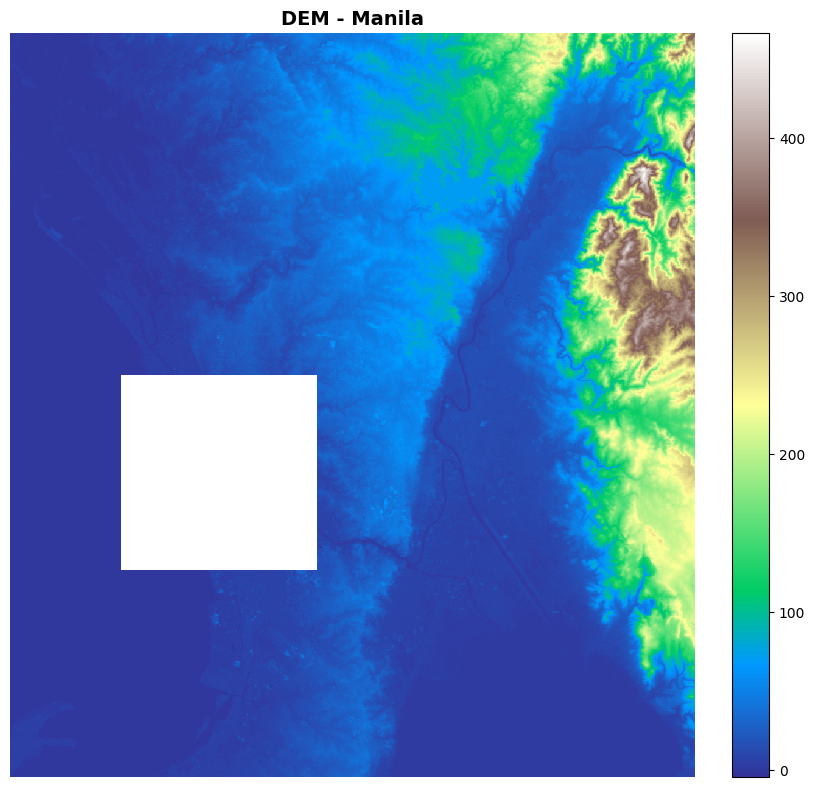

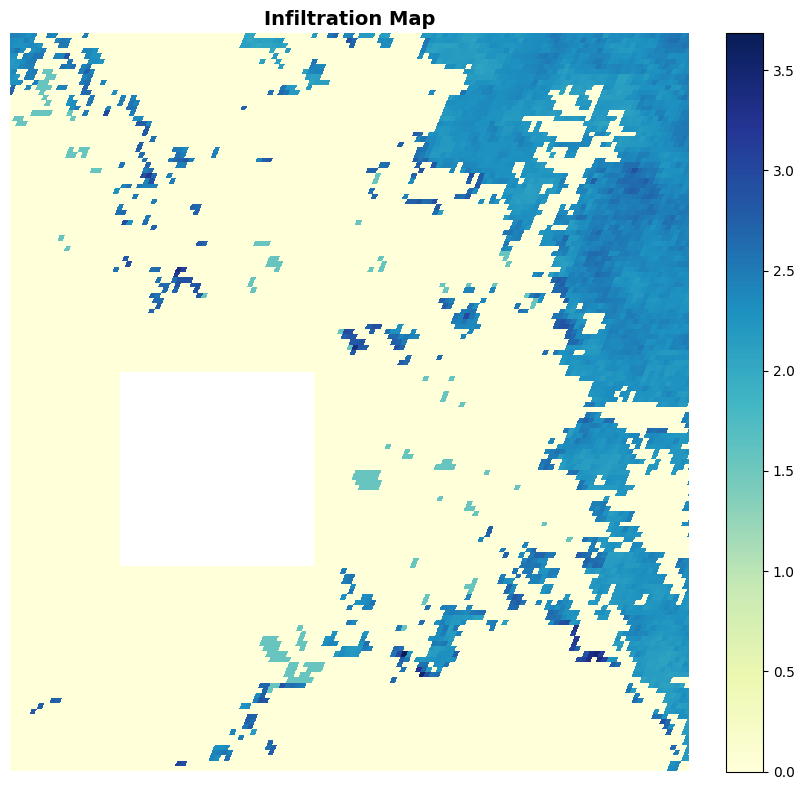

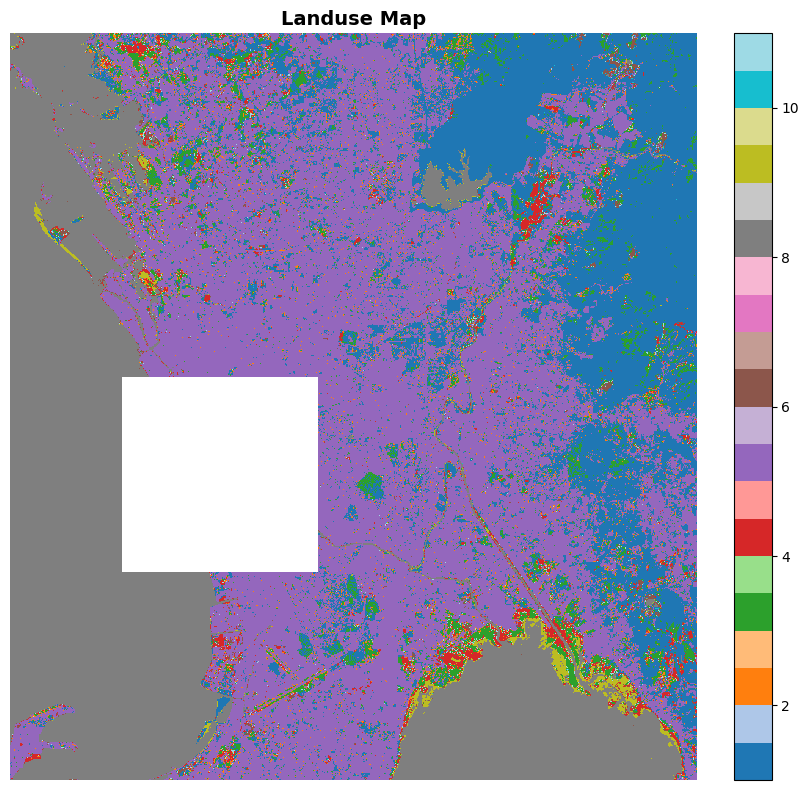

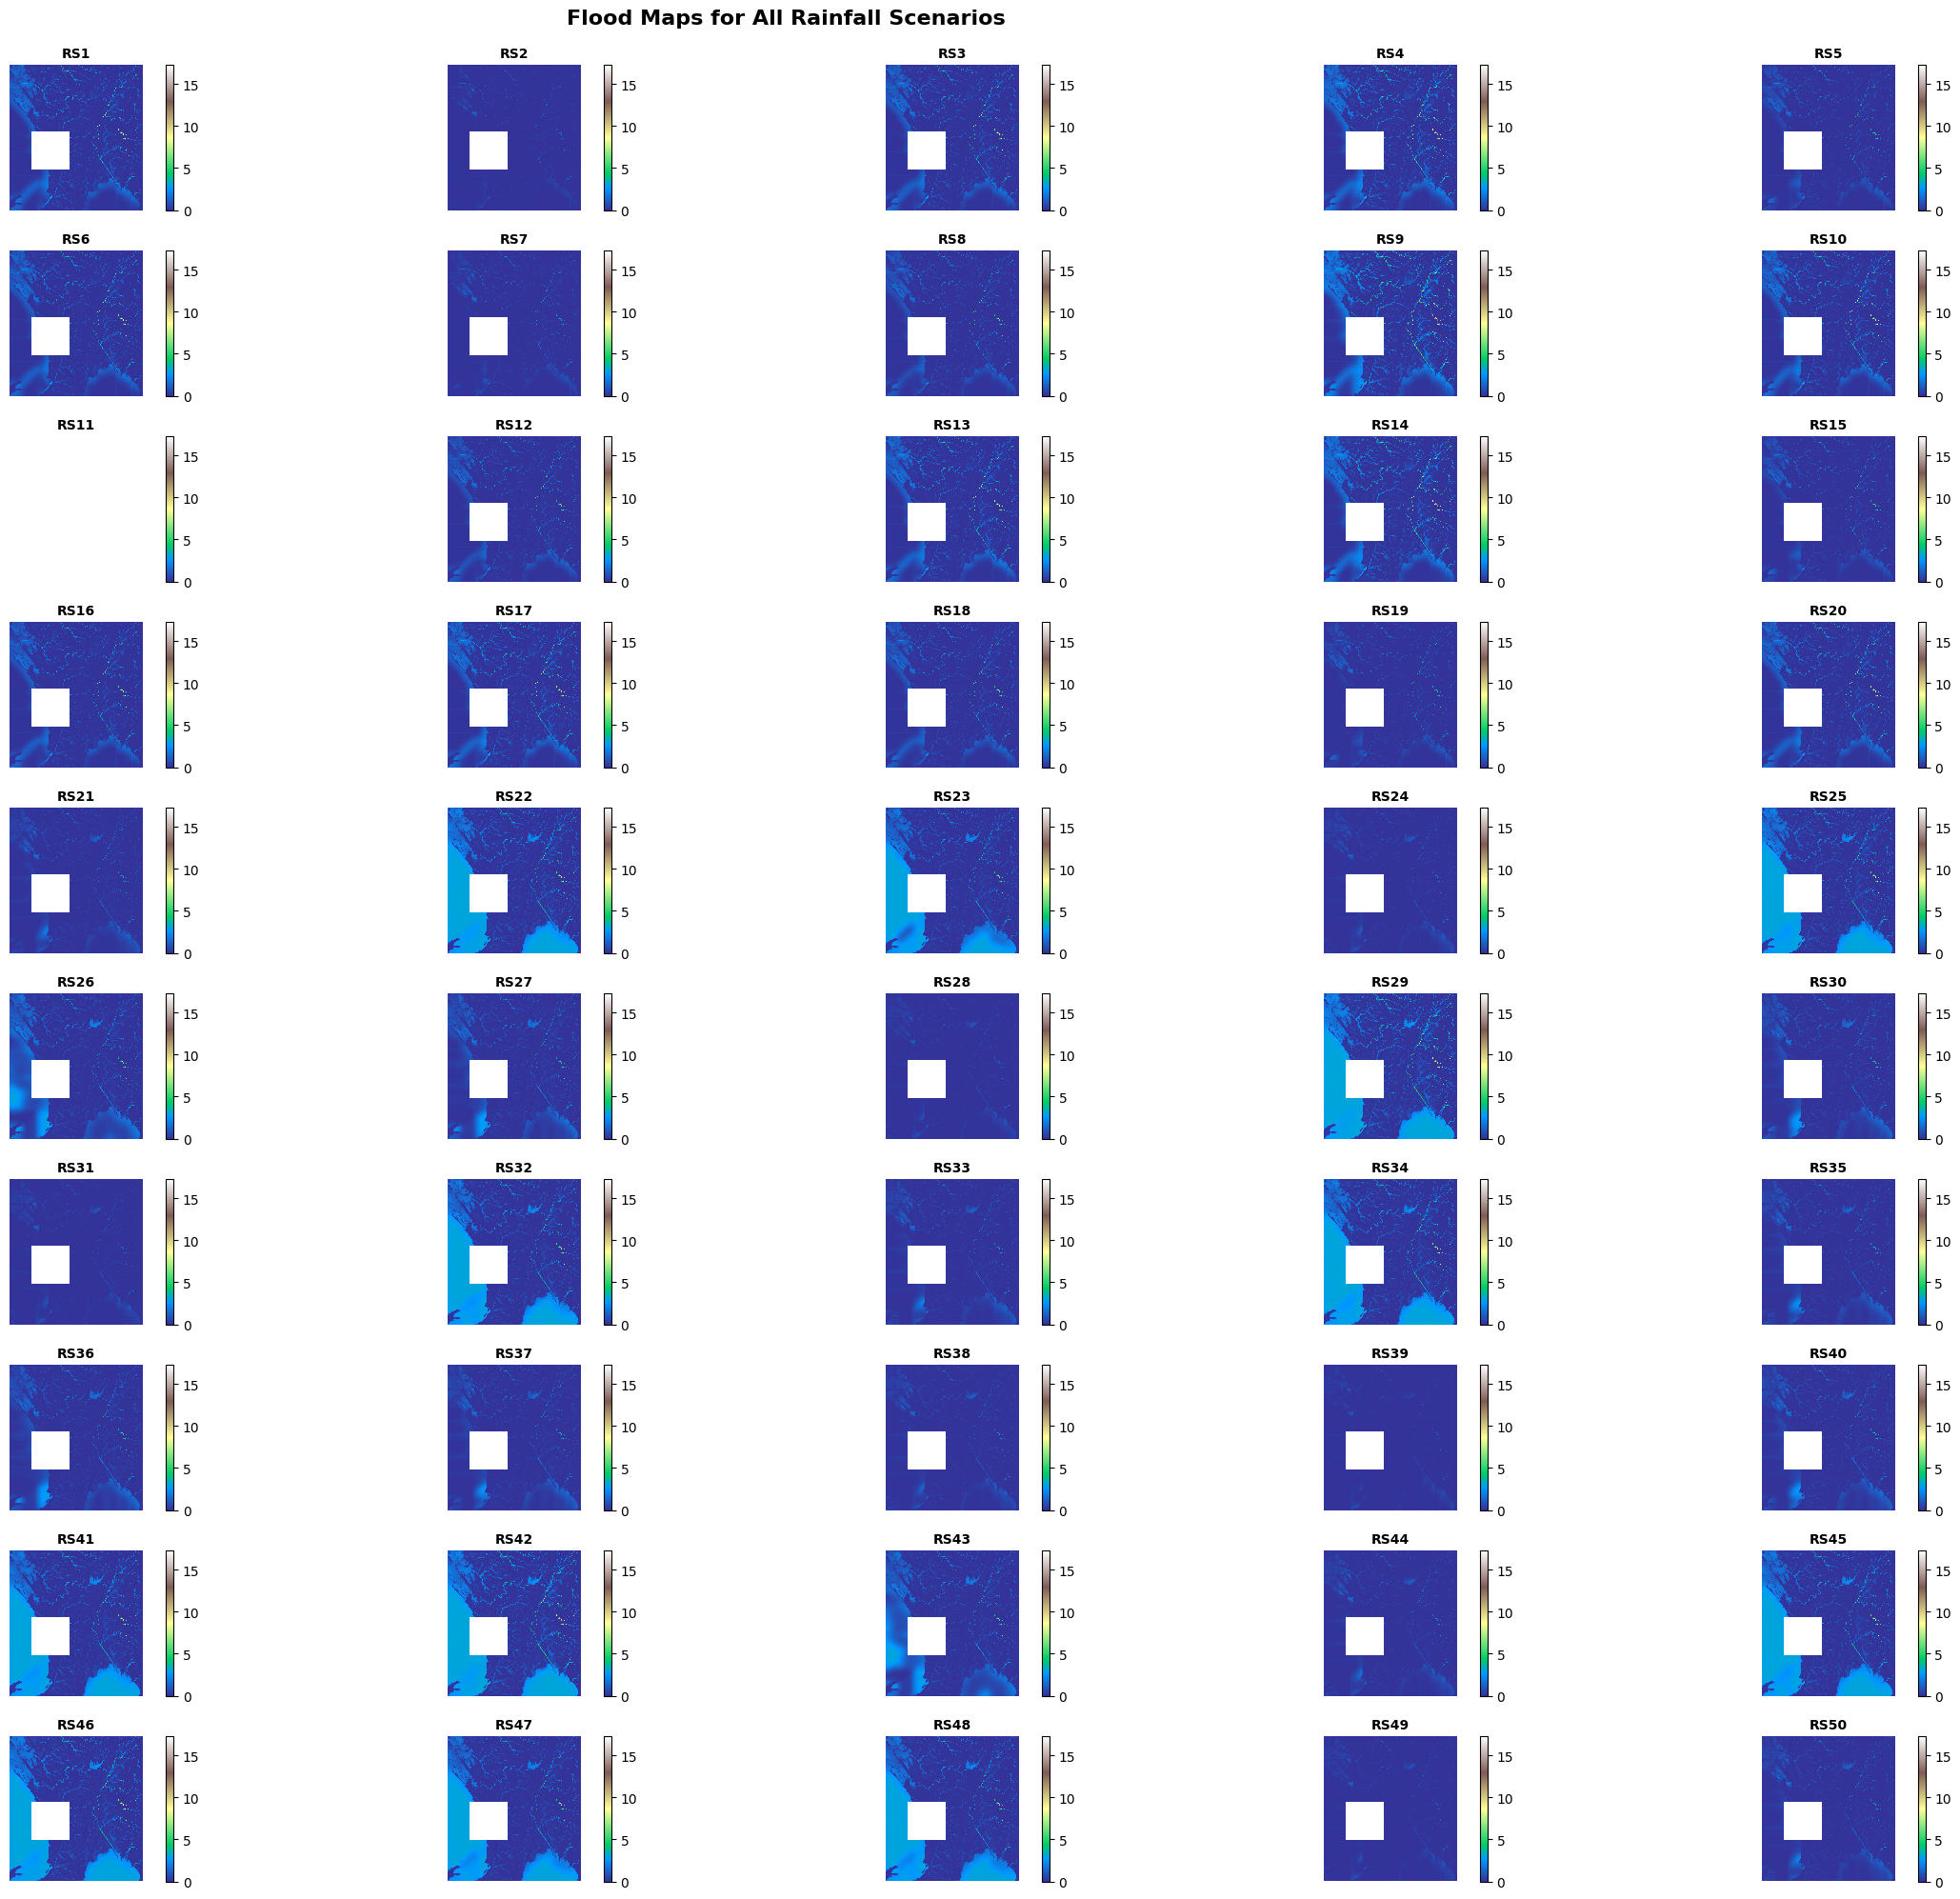

In [2]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")

fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None

fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_train) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
    
    if len(flood_maps_train) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_train,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

# Test Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1999
Std dev:       5.6200
Valid pixels:  103,041 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0126
Std dev:       0.1790
Valid pixels:  103,041 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7113
Std dev:       1.6436
Valid pixels:  103,041 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtyp

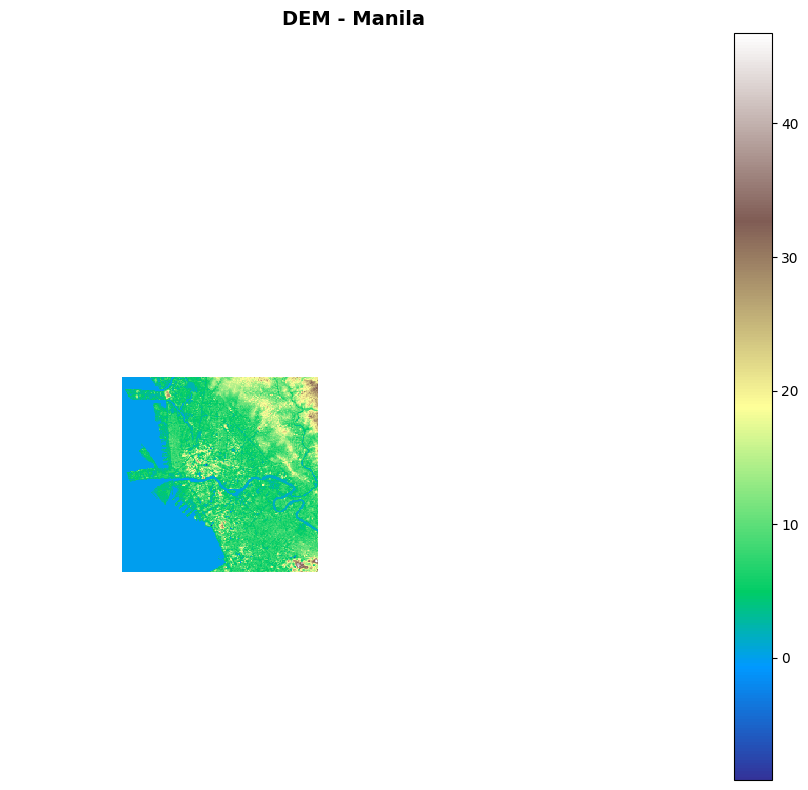

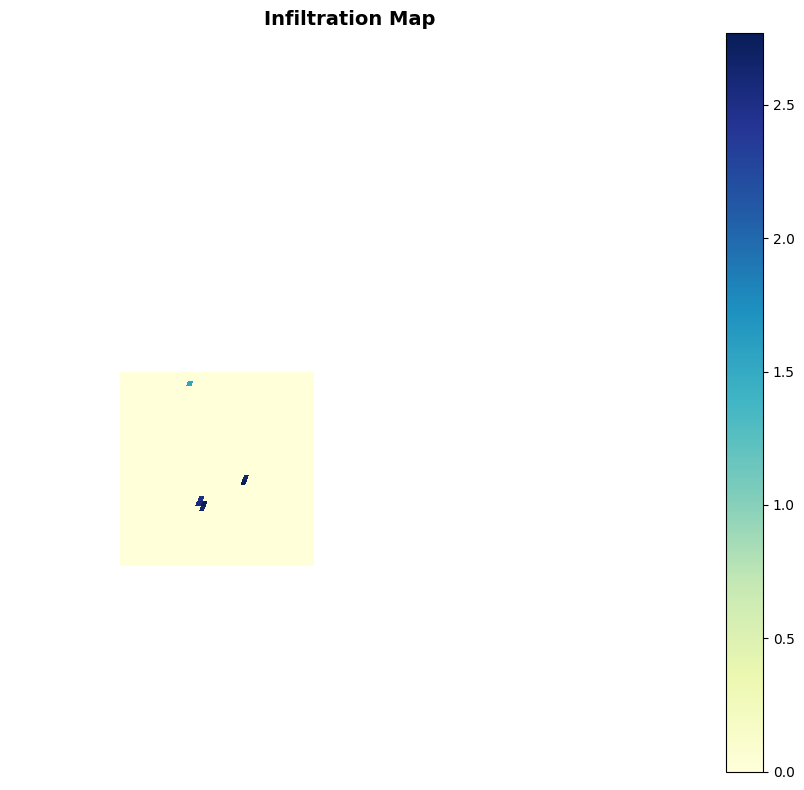

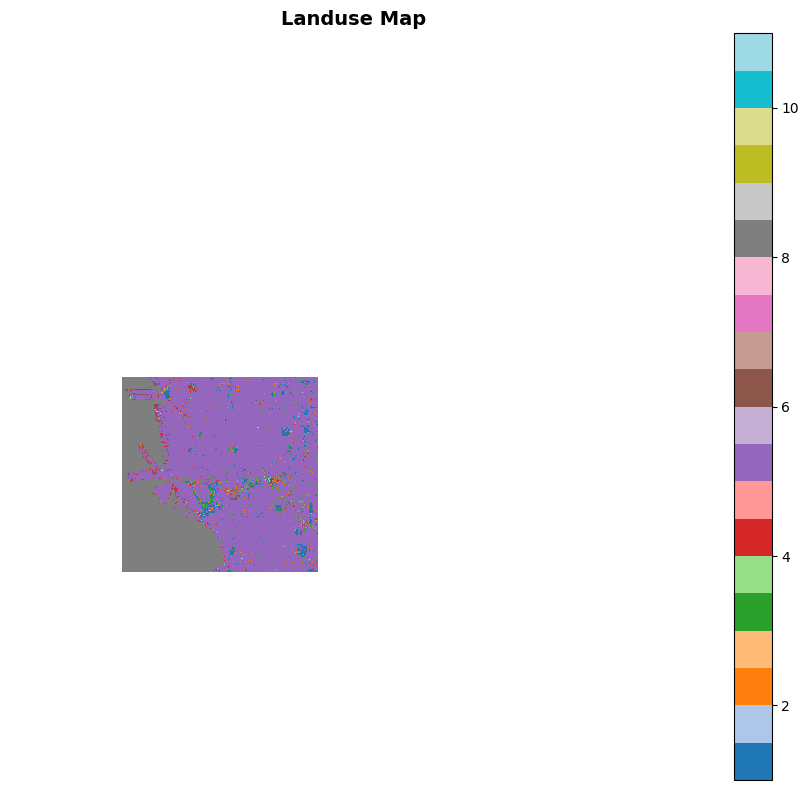

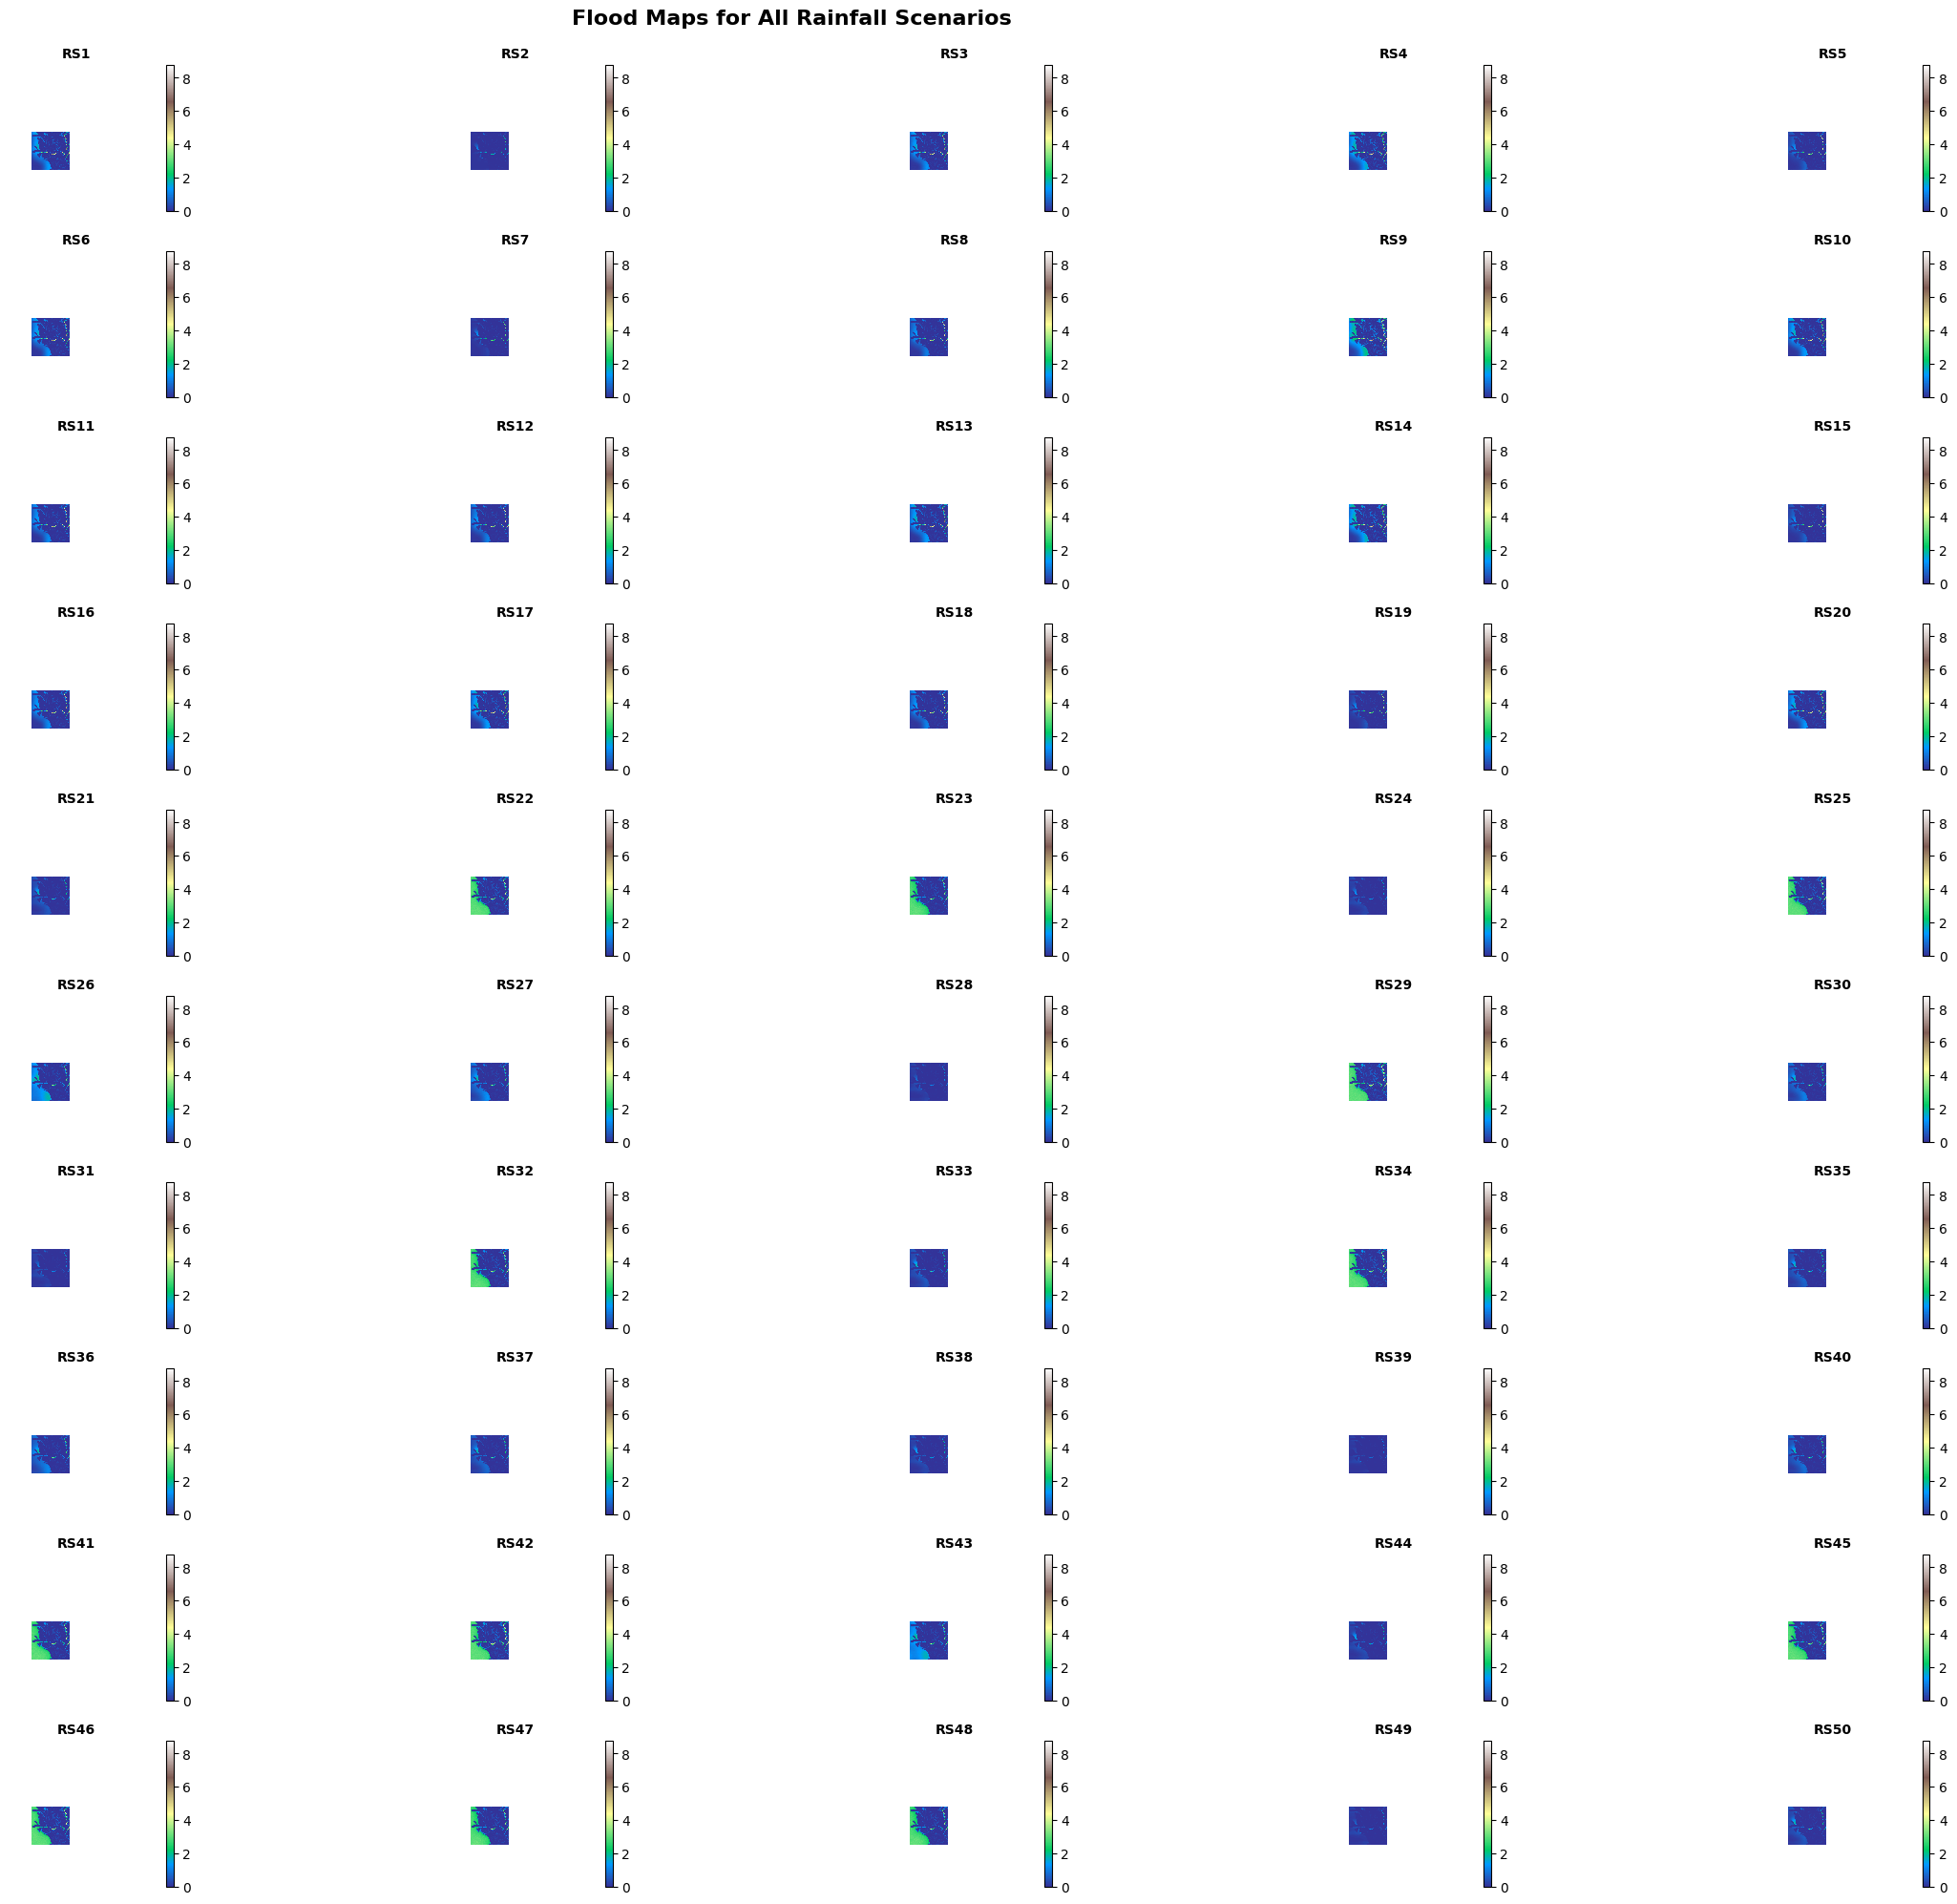

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data_test, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data_test, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data_test = None

fig1 = visualize_raster(dem_data_test, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data_test = None
fig2 = visualize_raster(infilt_data_test, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data_test = None
    
fig3 = visualize_raster(landuse_data_test, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_test) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_test)}")
    
    if len(flood_maps_test) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_test,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

# Manila Mask


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262


MANILA BOX MASK PROCESSING

Current mask shape: (389, 358)

Zoom factors: (3.146529562982005, 3.142458100558659)
Resized mask shape: (1224, 1125)
Unique values in resized mask: [0. 1.]

Statistics for: Manila Mask (Resized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0751
Std dev:       0.2635
Valid pixels:  1,377,000 / 1,377,000



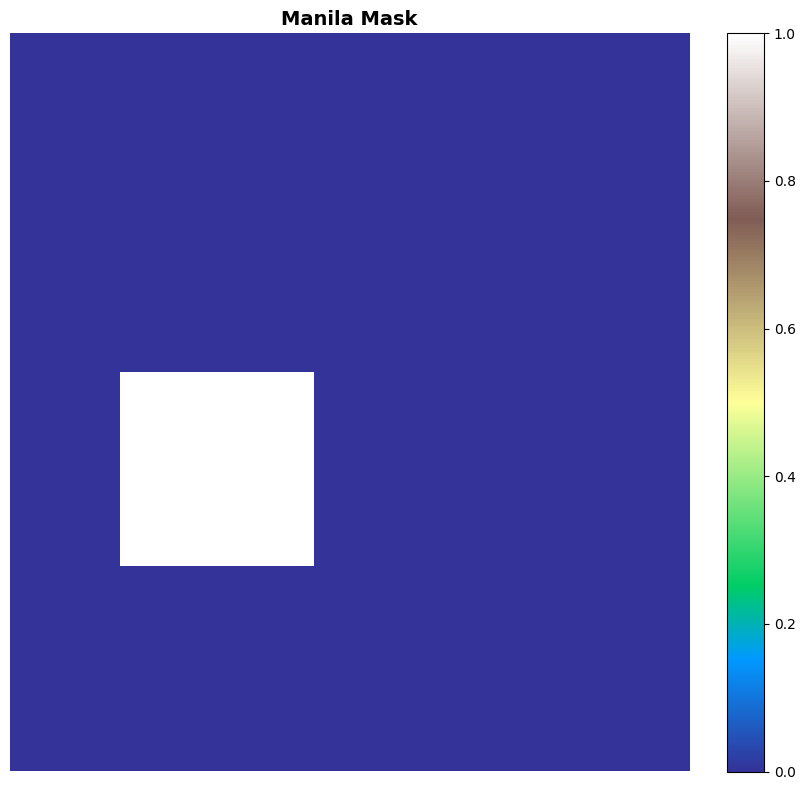

In [4]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')

print("\n" + "="*70)
print("MANILA BOX MASK PROCESSING")
print("="*70)

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized

In [5]:
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")

  - train_dem_data (train): (1224, 1125)
  - train_infilt_data (train): (1224, 1125)
  - train_landuse_data (train): (1224, 1125)
  - dem_data_test (test): (1224, 1125)
  - infilt_data_test (test): (1224, 1125)
  - landuse_data_test (test): (1224, 1125)
  - flood_maps_train (train): 50 maps
  - flood_maps_test (test): 50 maps


# Data Preprocessing

In [6]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)


PHASE 2: SPATIAL INPUT PREPROCESSING

[2.1] Handling NoData Values
----------------------------------------------------------------------
  DEM (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  DEM (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Infiltration (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Infiltration (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Landuse (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Landuse (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor

✓ NoData handling complete

[2.2] Resizing to (1152, 1152)
----------------------------------------------------------------------
  Current: (1224, 1125)
  Target: (1152, 1152)
  Train DEM: (1224, 1125) → (1152, 1152) (bilinear)
  Train Infiltration: (1224, 1125) → (1152, 1152) (bilinear)
  Train Landuse: (1224, 1125) → (1152, 1152) (nearest)
  T

In [7]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")

  - train_dem_preprocessed: (1152, 1152)
  - train_infilt_preprocessed: (1152, 1152)
  - train_landuse_preprocessed: (1152, 1152)
  - test_dem_preprocessed: (1152, 1152)
  - test_infilt_preprocessed: (1152, 1152)
  - test_landuse_preprocessed: (1152, 1152)
  - mask_preprocessed: (1152, 1152)
  - flood_maps_train: 50 scenarios
  - flood_maps_test: 50 scenarios


# Rainfall

In [8]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences, visualize_conditioning_vectors


print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
else:
    print("WARNING: No rainfall scenarios loaded!")

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(rainfall_scenarios=rainfall_scenarios, norm_method='global_max', info_csv_path='./info.csv')

# Output now includes:
rainfall_results['conditioning_vectors']  
rainfall_results['encoding_info'] 

LOADING RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 50

PHASE 3: RAINFALL TEMPORAL SEQUENCE PREPROCESSING

[3.1] Extracting Rainfall Sequences
----------------------------------------------------------------------
  RS01: 13 timesteps, peak=92.49 mm/hr at t=2
  RS02: 13 timesteps, peak=14.60 mm/hr at t=2
  RS03: 13 timesteps, peak=82.76 mm/hr at t=2
  RS04: 13 timesteps, peak=131.44 mm/hr at t=2
  RS05: 13 timesteps, peak=41.38 mm/hr at t=2
  RS06: 13 timesteps, peak=80.32 mm/hr at t=2
  RS07: 13 timesteps, peak=26.77 mm/hr at t=2
  RS08: 13 timesteps, peak=51.11 mm/hr at t=2
  RS09: 13 timesteps, peak=189.85 mm/hr at t=2
  RS10: 13 timesteps, peak=99.79 mm/hr at t=2
  RS11: 13 timesteps, peak=58.74 mm/hr at t=5
  RS20: 13 timesteps, peak=78.89 mm/hr at t=5
  RS21: 13 timesteps, peak=34.08 mm/hr at t=9
  RS30: 13 timesteps, peak=51.11 mm/hr at t=9
  RS31: 13 timesteps, peak=14.77 mm/hr at t=4
  RS50: 13 timesteps, peak=27.69 mm/hr at t=1

✓ Extracted 50 sequences
  Shap

{'pattern_encoding': {0: 'SCS‑style front-loaded (convective – similar to NRCS Type II)',
  1: 'SCS-style balanced (intermediate)',
  2: 'SCS-style back-loaded (frontal – similar to Type I)',
  3: 'Triangular / Chicago-style with peak at fraction of duration'},
 'max_depth_mm': 78.0,
 'conditioning_dims': 4,
 'dim_names': ['pattern_type', 'depth_normalized', 'tpeak', 'has_tpeak'],
 'pattern_names': ['Front-loaded', 'Balanced', 'Back-loaded', 'Triangular']}

# Ground Truth (Flood Maps)

In [9]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(flood_maps=flood_maps_train, target_shape=(1152, 1152), split_name='Train')
flood_maps_test_resized = resize_flood_maps(flood_maps=flood_maps_test, target_shape=(1152, 1152), split_name='Test')


Resizing Train Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Progress: 30/50 maps resized
    Progress: 35/50 maps resized
    Progress: 40/50 maps resized
    Progress: 45/50 maps resized
    Progress: 50/50 maps resized
  ✓ All flood maps resized to (1152, 1152)

Resizing Test Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Pro

In [10]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.15, 0.24, 0.46, 0.68]
)


PHASE 4: FLOOD MAP CATEGORIZATION

[4.1] Flood Susceptibility Classes
----------------------------------------------------------------------
  Class 0 - No Flood    : [0.00, 0.15) meters
  Class 1 - Light       : [0.15, 0.24) meters
  Class 2 - Moderate    : [0.24, 0.46) meters
  Class 3 - Heavy       : [0.46, 0.68) meters
  Class 4 - Extreme     : [0.68, ∞) meters

[4.2] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total patches: 82,944
  Categorization method: majority_vote

[4.3] Categorizing Flood Maps
----------------------------------------------------------------------

  Train Set (50 scenarios):
    RS01: 76,553 valid patches, 6,391 NoData
    RS02: 76,553 valid patches, 6,391 NoData
    RS03: 76,553 valid patches, 6,391 NoData
    RS04: 76,553 valid patches, 6,391 NoData
    RS05: 76,553 valid patches, 6,391 NoData
    RS06: 76,553 valid patches, 6

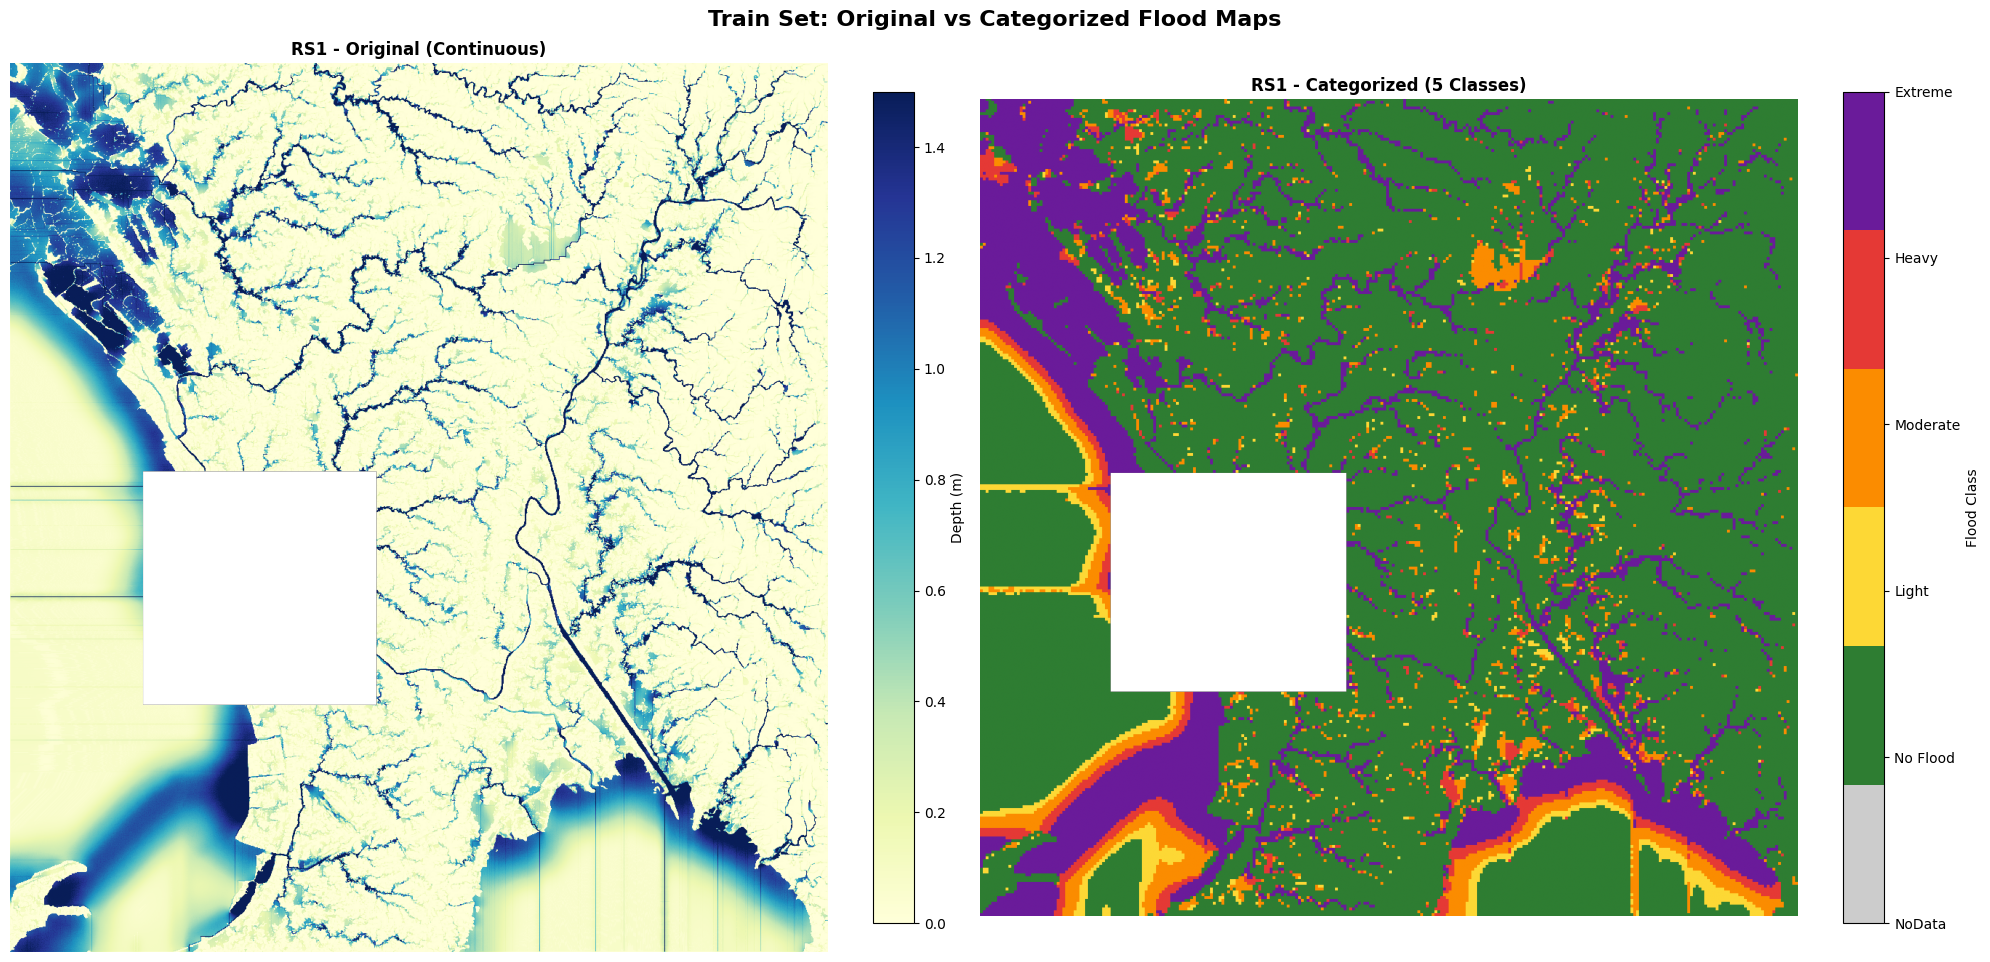

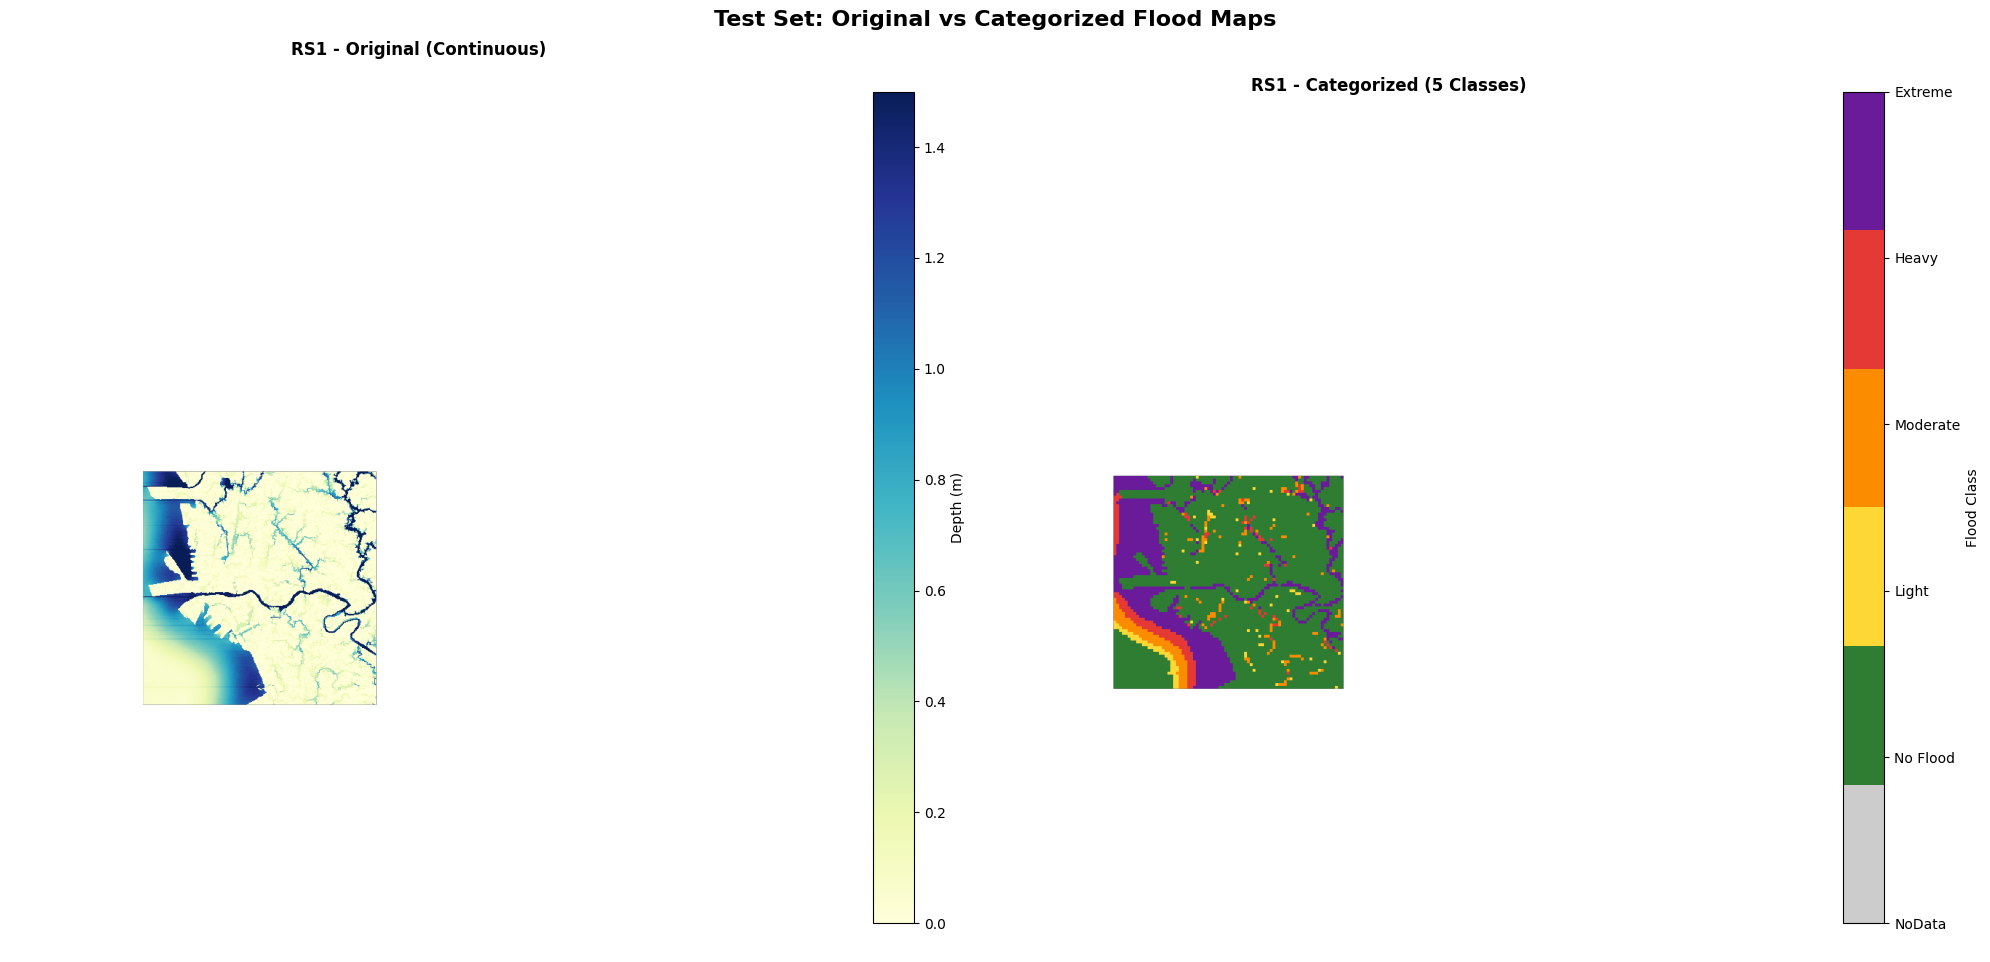

In [11]:
fig1 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_train, split='train', num_scenarios=1)
fig2 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_test, split='test', num_scenarios=1)

# Rainfall-based Partitioning

In [12]:
from data_splitting import split_spatial_data

split_results = split_spatial_data( 
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.70, random_seed=42, patch_size=PATCH_SIZE
)

# ── Training patches (GMM region, 35 scenarios) ───────────────────────────────
X_train_spatial      = split_results['train']['spatial_patches']       # (2_679_355, 3, 4, 4)
X_train_rainfall     = split_results['train']['rainfall_sequences']    # (2_679_355, 13)
X_train_conditioning = split_results['train']['conditioning_vectors']  # (2_679_355, 4)
y_train              = split_results['train']['labels']                 # (2_679_355,)
train_scenario_meta  = split_results['train']['scenario_metadata']     # list, len=2_679_355
train_scenario_ids   = split_results['train']['scenario_ids']          # list of 35 ints

# ── Test patches (Manila core, 15 scenarios) ──────────────────────────────────
X_test_spatial       = split_results['test']['spatial_patches']        # (91_125, 3, 4, 4)
X_test_rainfall      = split_results['test']['rainfall_sequences']     # (91_125, 13)
X_test_conditioning  = split_results['test']['conditioning_vectors']   # (91_125, 4)
y_test               = split_results['test']['labels']                  # (91_125,)
test_scenario_meta   = split_results['test']['scenario_metadata']      # list, len=91_125
test_scenario_ids    = split_results['test']['scenario_ids']           # list of 15 ints

print("Training arrays (patch-level):")
print(f"  X_train_spatial      : {X_train_spatial.shape}")
print(f"  X_train_rainfall     : {X_train_rainfall.shape}")
print(f"  X_train_conditioning : {X_train_conditioning.shape}")
print(f"  y_train              : {y_train.shape}")
print(f"  train scenarios      : {len(train_scenario_ids)}  → {train_scenario_ids}")

print("\nTest arrays (patch-level):")
print(f"  X_test_spatial       : {X_test_spatial.shape}")
print(f"  X_test_rainfall      : {X_test_rainfall.shape}")
print(f"  X_test_conditioning  : {X_test_conditioning.shape}")
print(f"  y_test               : {y_test.shape}")
print(f"  test scenarios       : {len(test_scenario_ids)}   → {test_scenario_ids}")



SPATIAL DATA SPLITTING (WITH CONDITIONING)

[5.1] Spatial Split Logic
----------------------------------------------------------------------
  Data Structure:
    • Train region: Greater Metro Manila (GMM) - outside Manila box
    • Test region: Metro Manila core - inside Manila box
    • Spatially complementary (non-overlapping)

  Split Strategy:
    • All 50 scenarios used for BOTH regions
    • Training scenarios → GMM patches
    • Testing scenarios → Manila patches
    • Conditioning vectors replicated per patch (NEW)

[5.2] Spatial Masks
----------------------------------------------------------------------
  Total pixels: 1,327,104
  GMM region (train): 1,227,417 pixels (92.5%)
  Manila region (test): 99,687 pixels (7.5%)
  Coverage check: 1,327,104 / 1,327,104 ✓

  Patch Alignment:
    Train (GMM): 76,553 patches
    Test (Manila): 6,075 patches

[5.3] Random Scenario Assignment
----------------------------------------------------------------------
  Total scenarios: 50
  Tra

In [13]:
import numpy as np
from pathlib import Path
from config import XGBConfig

cfg = XGBConfig()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

N_TEST_SCENARIOS   = 15
N_PATCHES_EXPECTED = 6075  

manila_mask = split_results['masks']['manila_mask'] 
H, W = manila_mask.shape

patch_rows, patch_cols = [], []
for r in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
    for c in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
        if manila_mask[r:r + PATCH_SIZE, c:c + PATCH_SIZE].mean() == 1.0:
            patch_rows.append(r)
            patch_cols.append(c)

patch_indices = np.stack([patch_rows, patch_cols], axis=1).astype(np.int32)

print(f"  manila_mask pixels    : {manila_mask.sum()}")          # 99687
print(f"  patch_indices derived : {patch_indices.shape[0]}")     # must be 6075
print(f"  X_test_spatial        : {X_test_spatial.shape}")       # (91125, 3, 4, 4)

assert patch_indices.shape[0] == N_PATCHES_EXPECTED, (
    f"Expected {N_PATCHES_EXPECTED}, got {patch_indices.shape[0]}. "
    f"Check PATCH_SIZE or manila_mask."
)

unique_spatial = X_test_spatial[:N_PATCHES_EXPECTED]

assert unique_spatial.shape == (N_PATCHES_EXPECTED, 3, PATCH_SIZE, PATCH_SIZE), \
    f"Unexpected unique_spatial shape: {unique_spatial.shape}"

# ── Save ───────────────────────────────────────────────────────────────────────
save_path = cfg.output_dir / 'test_patches.npz'
np.savez(
    save_path,
    spatial       = unique_spatial,        # (6075, 3, 4, 4)
    patch_indices = patch_indices,         # (6075, 2)
    dem           = test_dem_preprocessed, # (1152, 1152)
)

print(f"\n  ✓ Saved → {save_path}")
print(f"    spatial       : {unique_spatial.shape}")
print(f"    patch_indices : {patch_indices.shape}")
print(f"    dem           : {test_dem_preprocessed.shape}")

  manila_mask pixels    : 99687
  patch_indices derived : 6075
  X_test_spatial        : (91125, 3, 4, 4)

  ✓ Saved → outputs_xgb\test_patches.npz
    spatial       : (6075, 3, 4, 4)
    patch_indices : (6075, 2)
    dem           : (1152, 1152)


[compute_slope_map]  slope range: [0.000000, 0.103493]  mean=0.003912
slope_map shape : (1152, 1152)
slope_map range : [0.000000, 0.103493]
slope_map mean  : 0.003912


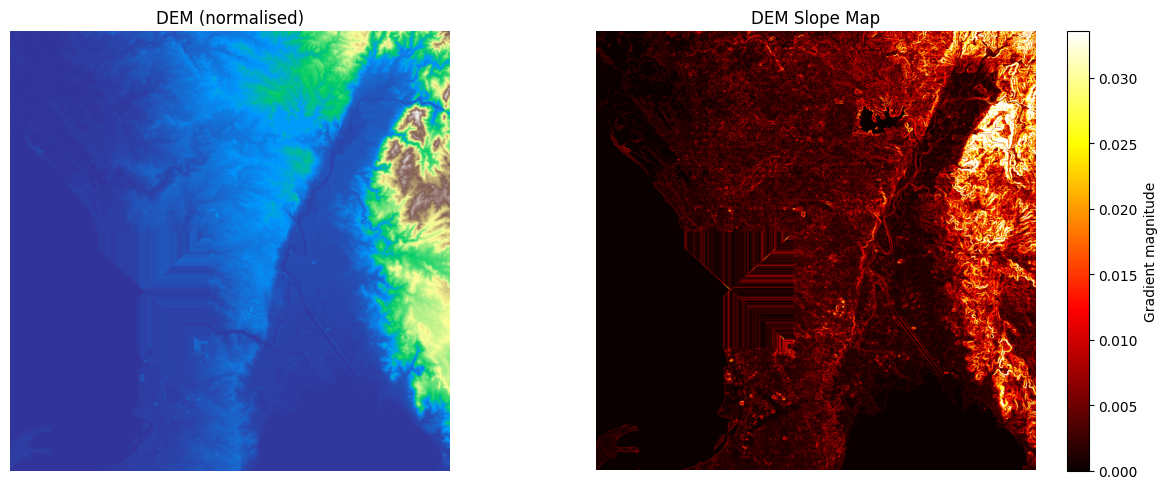

In [14]:
from feature_engineering import compute_slope_map

slope_map = compute_slope_map(train_dem_preprocessed) 

print(f"slope_map shape : {slope_map.shape}")
print(f"slope_map range : [{slope_map.min():.6f}, {slope_map.max():.6f}]")
print(f"slope_map mean  : {slope_map.mean():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(train_dem_preprocessed, cmap='terrain')
axes[0].set_title('DEM (normalised)'); axes[0].axis('off')
vmax = float(np.percentile(slope_map, 99))
im = axes[1].imshow(slope_map, cmap='hot', vmax=vmax)
plt.colorbar(im, ax=axes[1], label='Gradient magnitude')
axes[1].set_title('DEM Slope Map'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [15]:
# build_feature_matrix extracts 35 features per patch:
#   DEM        (7): mean, std, min, max, slope_mean, slope_std, entropy
#   Infilt     (5): mean, std, min, max, entropy
#   Land use   (3): mode, nunique, entropy
#   Rainfall  (16): t00..t12, total, peak, tpeak_idx
#   Cond       (4): pattern_type, depth_norm, tpeak, has_tpeak

from feature_engineering import build_feature_matrix, get_feature_names

feature_names = get_feature_names()
print(f"Feature vector: {len(feature_names)} features")
for i, n in enumerate(feature_names):
    print(f"  {i:>2}  {n}")

X_train_feat, _ = build_feature_matrix(
    spatial      = X_train_spatial,       # (2_679_355, 3, 4, 4)
    rainfall     = X_train_rainfall,      # (2_679_355, 13)
    conditioning = X_train_conditioning,  # (2_679_355, 4)
    slope_map    = slope_map,             # (1152, 1152) 
    patch_coords = None,                  
    entropy_bins = 16,
    chunk_size   = 250_000,
    verbose      = True,
)

Feature vector: 35 features
   0  dem_mean
   1  dem_std
   2  dem_min
   3  dem_max
   4  dem_slope_mean
   5  dem_slope_std
   6  dem_entropy
   7  infilt_mean
   8  infilt_std
   9  infilt_min
  10  infilt_max
  11  infilt_entropy
  12  landuse_mode
  13  landuse_nunique
  14  landuse_entropy
  15  rain_t00
  16  rain_t01
  17  rain_t02
  18  rain_t03
  19  rain_t04
  20  rain_t05
  21  rain_t06
  22  rain_t07
  23  rain_t08
  24  rain_t09
  25  rain_t10
  26  rain_t11
  27  rain_t12
  28  rain_total
  29  rain_peak
  30  rain_tpeak_idx
  31  cond_pattern_type
  32  cond_depth_norm
  33  cond_tpeak
  34  cond_has_tpeak
  ⚠ patch_coords not provided — deriving slope from spatial DEM channel

[build_feature_matrix]  N=2,679,355  F=35  chunks=11


  Features: 100%|██████████| 11/11 [04:01<00:00, 21.98s/it]


  ✓ Done  shape=(2679355, 35)  dtype=float32

  Feature                     Mean       Std       Min       Max
  ──────────────────────  ────────  ────────  ────────  ────────
  dem_mean                  0.1098    0.1499    0.0124    0.9863
  dem_std                   0.0045    0.0071    0.0000    0.0789
  dem_min                   0.1023    0.1418    0.0072    0.9695
  dem_max                   0.1178    0.1583    0.0124    1.0000
  dem_slope_mean            0.0044    0.0065    0.0000    0.0691
  dem_slope_std             0.0017    0.0021    0.0000    0.0270
  dem_entropy               2.3492    1.3898    0.0000    3.8750
  infilt_mean               0.1414    0.2555    0.0000    0.9953
  infilt_std                0.0159    0.0571    0.0000    0.4593
  infilt_min                0.1212    0.2460    0.0000    0.9508
  infilt_max                0.1632    0.2779    0.0000    1.0000
  infilt_entropy            0.2755    0.5883    0.0000    3.0778
  landuse_mode              0.2767    0.4474

In [16]:
X_test_feat, _ = build_feature_matrix(
    spatial      = X_test_spatial,        # (91_125, 3, 4, 4)
    rainfall     = X_test_rainfall,       # (91_125, 13)
    conditioning = X_test_conditioning,   # (91_125, 4)
    slope_map    = slope_map,
    patch_coords = None,
    entropy_bins = 16,
    chunk_size   = 100_000,
    verbose      = True,
)

print(f"\nX_train_feat : {X_train_feat.shape}")   # (2_679_355, 35)
print(f"X_test_feat  : {X_test_feat.shape}")      # (91_125, 35)

  ⚠ patch_coords not provided — deriving slope from spatial DEM channel

[build_feature_matrix]  N=91,125  F=35  chunks=1


  Features: 100%|██████████| 1/1 [00:05<00:00,  5.28s/it]

  ✓ Done  shape=(91125, 35)  dtype=float32

  Feature                     Mean       Std       Min       Max
  ──────────────────────  ────────  ────────  ────────  ────────
  dem_mean                  0.0274    0.0109    0.0145    0.0933
  dem_std                   0.0024    0.0022    0.0000    0.0215
  dem_min                   0.0237    0.0089    0.0000    0.0846
  dem_max                   0.0318    0.0137    0.0145    0.1102
  dem_slope_mean            0.0025    0.0023    0.0000    0.0179
  dem_slope_std             0.0013    0.0012    0.0000    0.0083
  dem_entropy               2.3313    1.3781    0.0000    3.7500
  infilt_mean               0.0035    0.0433    0.0000    0.7514
  infilt_std                0.0016    0.0194    0.0000    0.3528
  infilt_min                0.0016    0.0315    0.0000    0.7514
  infilt_max                0.0059    0.0625    0.0000    0.7514
  infilt_entropy            0.0102    0.1210    0.0000    2.3496
  landuse_mode              0.2821    0.4500  

In [17]:
# ── Validate feature matrices ──────────────────────────────────────
from feature_engineering import validate_feature_matrix

validate_feature_matrix(X_train_feat, y_train, feature_names, split='train')
validate_feature_matrix(X_test_feat,  y_test,  feature_names, split='test')


[validate_feature_matrix]  split=train
  Shape      : (2679355, 35)  ✓
  NaN        : 0  ✓
  Inf        : 0  ✓
  Labels     : [0, 1, 2, 3, 4]  ✓

  Class distribution:
    Class 0 (No Flood  ):  1,949,258  ( 72.8%)
    Class 1 (Light     ):     70,542  (  2.6%)
    Class 2 (Moderate  ):    131,437  (  4.9%)
    Class 3 (Heavy     ):     74,375  (  2.8%)
    Class 4 (Extreme   ):    453,743  ( 16.9%)
  Slope ≥ 0  : ✓

  ✓ All checks passed

[validate_feature_matrix]  split=test
  Shape      : (91125, 35)  ✓
  NaN        : 0  ✓
  Inf        : 0  ✓
  Labels     : [0, 1, 2, 3, 4]  ✓

  Class distribution:
    Class 0 (No Flood  ):     66,064  ( 72.5%)
    Class 1 (Light     ):      2,987  (  3.3%)
    Class 2 (Moderate  ):      6,152  (  6.8%)
    Class 3 (Heavy     ):      2,963  (  3.3%)
    Class 4 (Extreme   ):     12,959  ( 14.2%)
  Slope ≥ 0  : ✓

  ✓ All checks passed


True

# K-Fold Training

In [21]:
# ── Config + K-Fold Training ───────────────────────────────────────
from config import XGBConfig
from training import train_kfold_xgb
import matplotlib.pyplot as plt

cfg_xgb = XGBConfig()

# GPU users — uncomment:
# cfg_xgb.device      = 'cuda'
# cfg_xgb.tree_method = 'hist'   # works for both CPU and GPU in XGBoost ≥ 2.0

cfg_xgb.summary()

fold_results, best_fold_idx = train_kfold_xgb(
    X_train       = X_train_feat,   # (2_679_355, 35)
    y_train       = y_train,        # (2_679_355,)
    cfg           = cfg_xgb,
    feature_names = feature_names,
)

print(f"\nBest fold         : {best_fold_idx + 1}")
print(f"Best val Macro F1 : {fold_results[best_fold_idx]['val_macro_f1']:.4f}")


XGBConfig
  Features       : 35 total per patch
    DEM          : mean, std, min, max, slope_mean, slope_std, entropy  (7)
    Infiltration : mean, std, min, max, entropy                         (5)
    Land use     : mode, n_unique, entropy                              (3)
    Rainfall     : 13 timesteps + total / peak / tpeak_idx             (16)
    Conditioning : pattern_type, depth_norm, tpeak, has_tpeak           (4)
  Estimators     : 500  (early_stop=30)
  Max depth      : 6
  LR (eta)       : 0.1
  Subsample      : rows=0.8  cols=0.8
  Regularisation : gamma=0.1  L1=0.0  L2=1.0
  Class weights  : ✓  power=0.5
  CV strategy    : 2-fold on patch indices  ⚠ val F1 optimistic
  Device         : cpu  tree_method=hist
  Output dir     : outputs_xgb

XGBoost 2-Fold Training  (patch-level split, mirrors ViT)
  Total patches : 2,679,355
  Features      : 35
  ⚠  Scenario leakage across folds — val F1 is optimistic

────────────────────────────────────────────────────────────
FOLD 1 /

c:\Users\mikos\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:54:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:0.98514
[50]	validation_0-mlogloss:0.61242
[100]	validation_0-mlogloss:0.59905
[150]	validation_0-mlogloss:0.58851
[200]	validation_0-mlogloss:0.58025
[250]	validation_0-mlogloss:0.57227
[300]	validation_0-mlogloss:0.56533
[350]	validation_0-mlogloss:0.55885
[400]	validation_0-mlogloss:0.55278
[450]	validation_0-mlogloss:0.54690
[499]	validation_0-mlogloss:0.54136

  Best round : 500  (of 500 max)

Fold 1 Validation Metrics
  Accuracy     : 0.8169
  Macro F1     : 0.4806
  Weighted F1  : 0.8161
  Critical Recall (Heavy+Extreme): 0.7256

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.9106   0.9130   0.9118
  Light          0.1809   0.2588   0.2130
  Moderate       0.3084   0.2874   0.2975
  Heavy          0.3198   0.1879   0.2367
  Extreme        0.7413   0.7474   0.7443

  Top-5 features by gain:
    1. cond_pattern_type       0.1973
    2. cond_has_tpeak          0.0813
    3. rain_t11                0.07

c:\Users\mikos\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:57:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:0.97943
[50]	validation_0-mlogloss:0.61217
[100]	validation_0-mlogloss:0.59842
[150]	validation_0-mlogloss:0.58827
[200]	validation_0-mlogloss:0.57958
[250]	validation_0-mlogloss:0.57159
[300]	validation_0-mlogloss:0.56467
[350]	validation_0-mlogloss:0.55808
[400]	validation_0-mlogloss:0.55212
[450]	validation_0-mlogloss:0.54688
[499]	validation_0-mlogloss:0.54145

  Best round : 500  (of 500 max)

Fold 2 Validation Metrics
  Accuracy     : 0.8162
  Macro F1     : 0.4816
  Weighted F1  : 0.8158
  Critical Recall (Heavy+Extreme): 0.7193

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.9108   0.9115   0.9111
  Light          0.1793   0.2727   0.2164
  Moderate       0.3007   0.2953   0.2979
  Heavy          0.3744   0.1750   0.2385
  Extreme        0.7405   0.7474   0.7439

  Top-5 features by gain:
    1. cond_pattern_type       0.1947
    2. rain_t11                0.0790
    3. cond_depth_norm         0.07

  Fold plot → outputs_xgb\logs\fold_summary.png


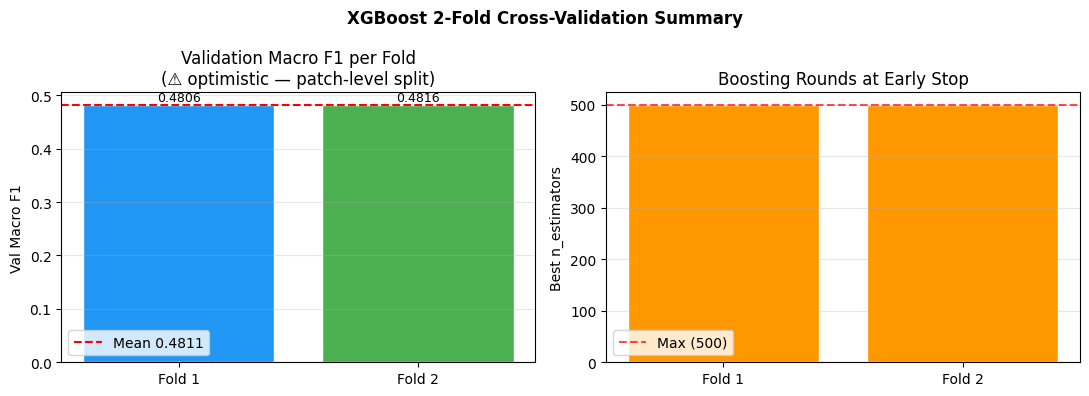

In [22]:
from training import plot_fold_histories_xgb, make_xgb_model, evaluate_xgb, plot_feature_importance

fig_folds = plot_fold_histories_xgb(fold_results, cfg_xgb)
plt.show()

# Test


Running Test evaluation on 91,125 patches...

Test Metrics
  Accuracy     : 0.8156
  Macro F1     : 0.4023
  Weighted F1  : 0.7852
  Critical Recall (Heavy+Extreme): 0.6623

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.8700   0.9659   0.9154
  Light          0.1603   0.2420   0.1929
  Moderate       0.3326   0.0504   0.0875
  Heavy          0.2189   0.0351   0.0605
  Extreme        0.7897   0.7230   0.7549

  Confidence — mean=0.7245  median=0.7955  std=0.2275  range=[0.2169, 0.9999]
  Low(<0.5)=20.0%  Mid=30.7%  High(>0.8)=49.3%
  Results → outputs_xgb\logs/test_results.json
  Feature importance plot → outputs_xgb\logs\feature_importance_gain.png


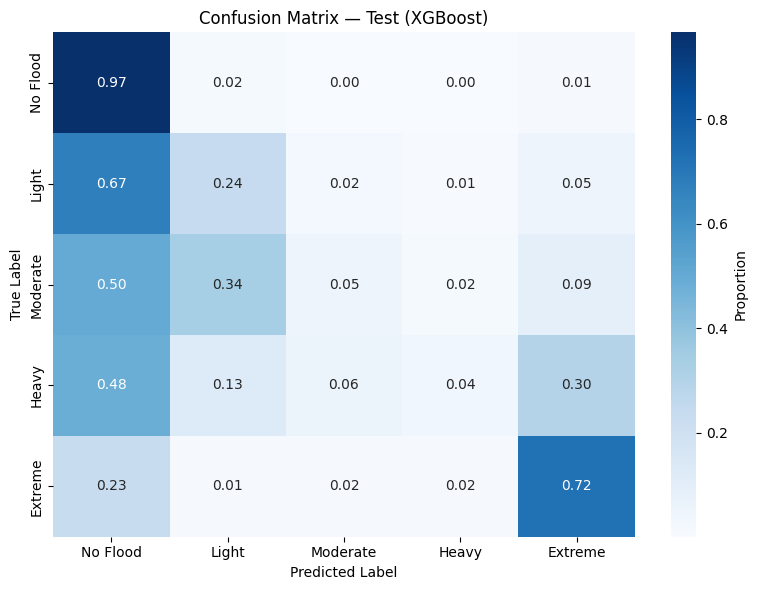

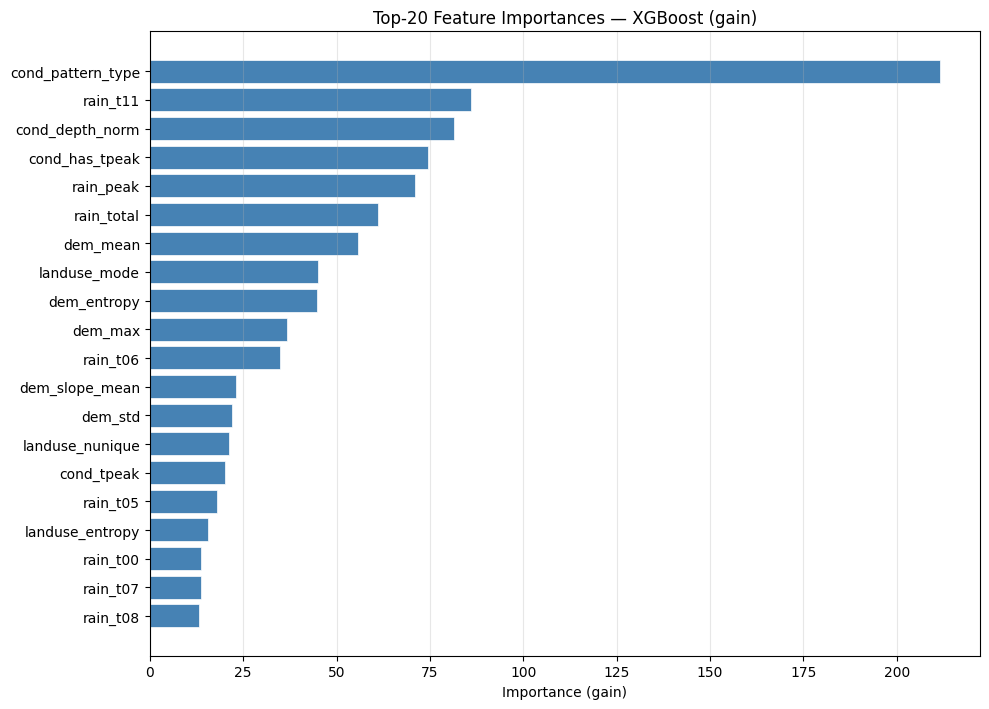

In [23]:
best_model_xgb = make_xgb_model(cfg_xgb)
best_model_xgb.load_model(str(cfg_xgb.output_dir / 'checkpoints' / f'fold_{best_fold_idx+1}_best.json'))

metrics_xgb = evaluate_xgb(best_model_xgb, X_test_feat, y_test, cfg_xgb, split_name='Test')

fig_fi = plot_feature_importance(best_model_xgb, feature_names, cfg_xgb, top_n=20, importance_type='gain')
plt.show()

In [24]:
import numpy as np
from pathlib import Path

cfg_xgb.output_dir.joinpath('predictions').mkdir(parents=True, exist_ok=True)

PATCH_SIZE    = 4
SPATIAL_SHAPE = (1152, 1152)

y_pred_test  = best_model_xgb.predict(X_test_feat)         # (91_125,)
y_proba_test = best_model_xgb.predict_proba(X_test_feat)   # (91_125, 5)

prediction_maps = {}
gt_maps         = {}

for s_idx, sid in enumerate(test_scenario_ids):
    # Collect patch indices belonging to this scenario
    patch_idx_list = [
        i for i, m in enumerate(test_scenario_meta)
        if m['scenario_id'] == sid
    ]

    pred_map = np.full(SPATIAL_SHAPE, -1,  dtype=np.int8)
    prob_map = np.zeros(SPATIAL_SHAPE + (5,), dtype=np.float32)
    gt_map   = np.full(SPATIAL_SHAPE, -1,  dtype=np.int8)

    for idx in patch_idx_list:
        i, j = test_scenario_meta[idx]['patch_coord']
        row, col = i * PATCH_SIZE, j * PATCH_SIZE
        sl = (slice(row, row+PATCH_SIZE), slice(col, col+PATCH_SIZE))
        pred_map[sl] = int(y_pred_test[idx])
        prob_map[sl] = y_proba_test[idx]
        gt_map[sl]   = int(y_test[idx])

    conf_map = prob_map.max(axis=2)

    prediction_maps[sid] = {
        'prediction_map' : pred_map,
        'probability_map': prob_map,
        'confidence_map' : conf_map,
    }
    gt_maps[sid] = gt_map

    valid_px = (pred_map >= 0).sum()
    print(f"  Scenario {sid:>2}: {valid_px:,} valid pixels  "
          f"(patches: {len(patch_idx_list)})")

print(f"\n✓ Reconstructed {len(prediction_maps)} prediction maps")

# Confidence summary across all valid pixels
conf_all = np.concatenate([
    v['confidence_map'][v['prediction_map'] >= 0].flatten()
    for v in prediction_maps.values()
])
print(f"  Confidence — mean={conf_all.mean():.4f}  median={np.median(conf_all):.4f}"
      f"  std={conf_all.std():.4f}")
print(f"  Low(<0.5)={100*(conf_all<0.5).mean():.1f}%"
      f"  Mid={100*((conf_all>=0.5)&(conf_all<0.8)).mean():.1f}%"
      f"  High(>0.8)={100*(conf_all>0.8).mean():.1f}%")



  Scenario  3: 97,200 valid pixels  (patches: 6075)
  Scenario  8: 97,200 valid pixels  (patches: 6075)
  Scenario 11: 97,200 valid pixels  (patches: 6075)
  Scenario 15: 97,200 valid pixels  (patches: 6075)
  Scenario 19: 97,200 valid pixels  (patches: 6075)
  Scenario 21: 97,200 valid pixels  (patches: 6075)
  Scenario 23: 97,200 valid pixels  (patches: 6075)
  Scenario 24: 97,200 valid pixels  (patches: 6075)
  Scenario 29: 97,200 valid pixels  (patches: 6075)
  Scenario 36: 97,200 valid pixels  (patches: 6075)
  Scenario 39: 97,200 valid pixels  (patches: 6075)
  Scenario 41: 97,200 valid pixels  (patches: 6075)
  Scenario 43: 97,200 valid pixels  (patches: 6075)
  Scenario 44: 97,200 valid pixels  (patches: 6075)
  Scenario 50: 97,200 valid pixels  (patches: 6075)

✓ Reconstructed 15 prediction maps
  Confidence — mean=0.7245  median=0.7955  std=0.2275
  Low(<0.5)=20.0%  Mid=30.7%  High(>0.8)=49.3%


In [ ]:
from prediction import reconstruct_ground_truth_maps_xgb

gt_maps = reconstruct_ground_truth_maps_xgb(
   test_scenario_meta = test_scenario_meta,  
    y_test             = y_test,             
    test_scenario_ids  = test_scenario_ids,    
    patch_size         = PATCH_SIZE,
    spatial_shape      = (1152, 1152),
)



[Reconstructing Ground Truth Maps — XGBoost]
  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels
  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels
  Scenario 19: 97,200 valid pixels
  Scenario 21: 97,200 valid pixels
  Scenario 23: 97,200 valid pixels
  Scenario 24: 97,200 valid pixels
  Scenario 29: 97,200 valid pixels
  Scenario 36: 97,200 valid pixels
  Scenario 39: 97,200 valid pixels
  Scenario 41: 97,200 valid pixels
  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels
  Scenario 50: 97,200 valid pixels
✓ Reconstructed 15 ground truth maps


In [27]:
from prediction import generate_prediction_maps_xgb

y_pred_test  = best_model_xgb.predict(X_test_feat)         # (91_125,)
y_proba_test = best_model_xgb.predict_proba(X_test_feat)   # (91_125, 5)

pred_results = generate_prediction_maps_xgb(
    y_pred_flat        = y_pred_test,
    y_proba_flat       = y_proba_test,
    test_scenario_meta = test_scenario_meta,
    test_scenario_ids  = test_scenario_ids,
    cfg                = cfg_xgb,
    patch_size         = PATCH_SIZE,
    spatial_shape      = (1152, 1152),
)
prediction_maps = pred_results['predictions'] 


PREDICTION PIPELINE (XGBoost)


  Assembling maps:  13%|█▎        | 2/15 [00:00<00:00, 18.60it/s]

  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels
  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels


  Assembling maps:  33%|███▎      | 5/15 [00:00<00:00, 21.52it/s]

  Scenario 19: 97,200 valid pixels
  Scenario 21: 97,200 valid pixels


...

  Scenario 36: 97,200 valid pixels
  Scenario 39: 97,200 valid pixels


  Assembling maps:  93%|█████████▎| 14/15 [00:00<00:00, 21.73it/s]

  Scenario 41: 97,200 valid pixels
  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels


  Assembling maps: 100%|██████████| 15/15 [00:00<00:00, 21.40it/s]


  Scenario 50: 97,200 valid pixels

  Confidence — mean=0.7245  median=0.7955  std=0.2275  range=[0.2169, 0.9999]
  Low(<0.5)=20.0%  Mid=30.7%  High(>0.8)=49.3%

✓ Done — results in: outputs_xgb\predictions



✓ Eval: 15 scenarios  |  Best  RS43  F1=0.383  |  Worst RS8 F1=0.241

Best  scenario : RS43
Worst scenario : RS8


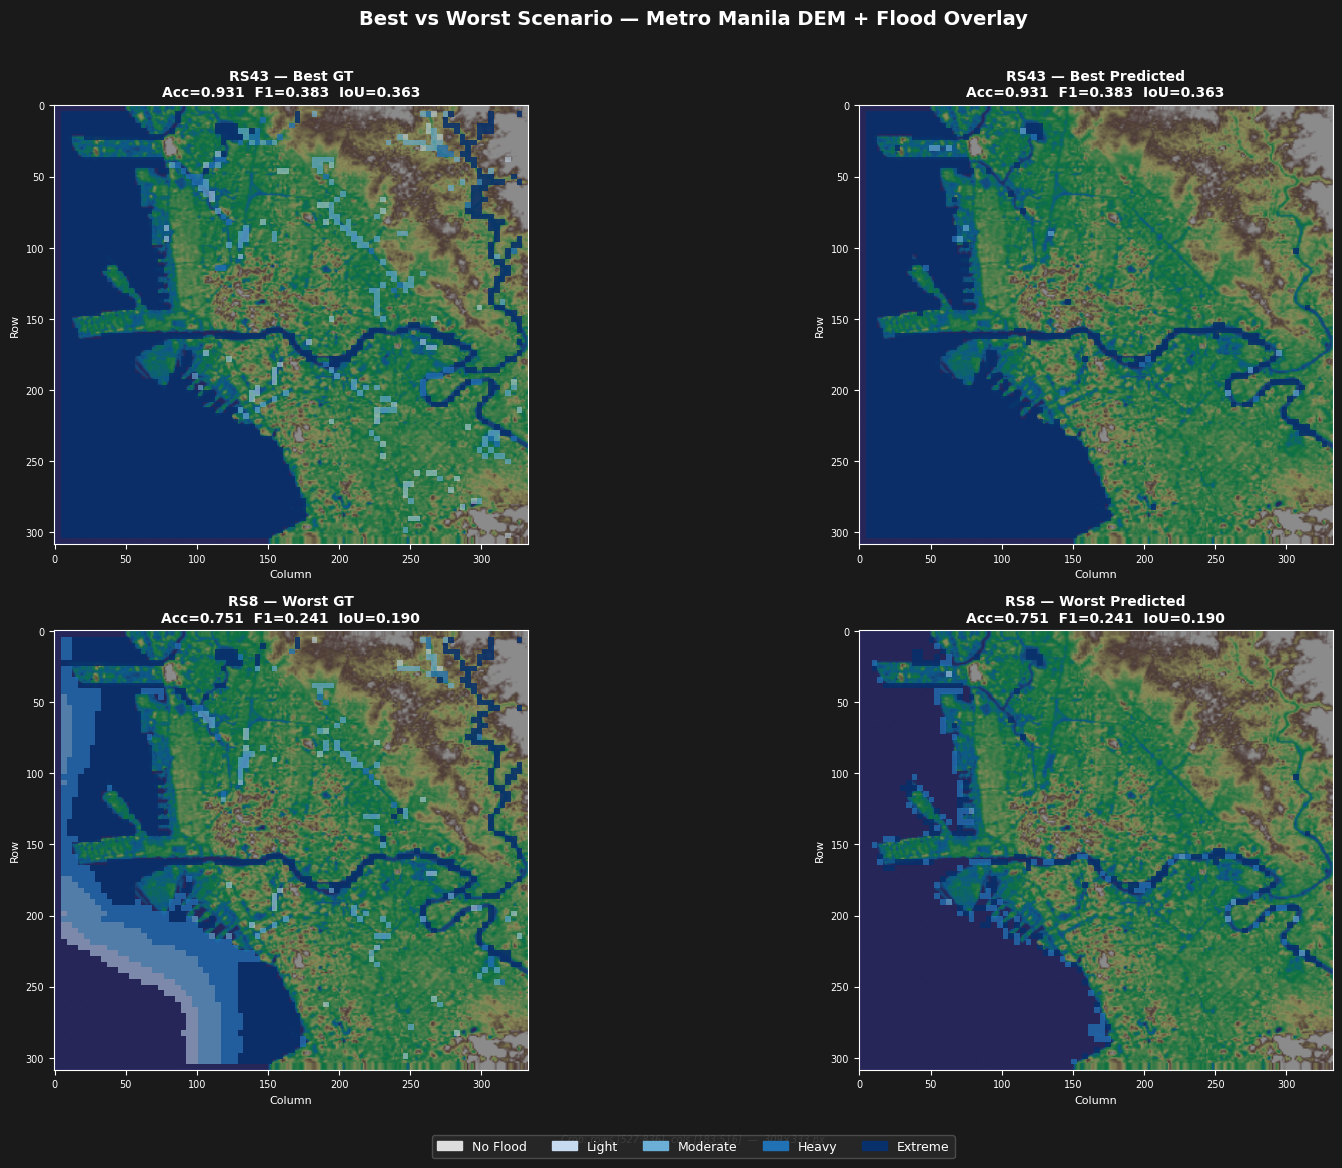

In [31]:
from prediction import build_eval_results, plot_best_worst_dem, plot_flood_on_dem

eval_results_xgb = build_eval_results(gt_maps, prediction_maps, cfg_xgb)

best_sid  = eval_results_xgb['aggregate']['best_scenario']
worst_sid = eval_results_xgb['aggregate']['worst_scenario']
print(f"\nBest  scenario : RS{best_sid}")
print(f"Worst scenario : RS{worst_sid}")


fig_grid = plot_best_worst_dem(
    dem     = test_dem_preprocessed.astype(np.float32),
    results = eval_results_xgb,
    figsize = (18, 11),
)
fig_grid.savefig(
    cfg_xgb.output_dir / 'predictions' / 'eval_dem_best_worst_grid.png',
    dpi=150, bbox_inches='tight',
)
plt.show()